In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [9]:
from google.colab import files

uploaded = files.upload()


Saving train (1).csv to train (1).csv


In [10]:
df = pd.read_csv("train.csv")

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [11]:
print("Shape:", df.shape)

print("\nColumns:")

print(df.columns)

print("\nInformation:")

df.info()

Shape: (891, 12)

Columns:
Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [12]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [13]:
print("Missing Values:")
df.isnull().sum()

Missing Values:


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [14]:
# Fill missing Age values with the median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill missing Embarked values with the mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Drop Cabin because most values are missing
df.drop(columns=["Cabin"], inplace=True)

print("Missing values handled successfully!")

Missing values handled successfully!


In [15]:
print("Duplicate Rows:", df.duplicated().sum())

df.drop_duplicates(inplace=True)


Duplicate Rows: 0


In [16]:
print(df.isnull().sum())


PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Embarked     891 non-null    object 
dtypes: float64(2), int64(5), object(4)
memory usage: 76.7+ KB


In [18]:
print("========== MEAN ==========")
print(df.mean(numeric_only=True))

print("\n========== MEDIAN ==========")
print(df.median(numeric_only=True))

print("\n========== MODE ==========")
print(df.mode().iloc[0])

print("\n========== VARIANCE ==========")
print(df.var(numeric_only=True))

print("\n========== STANDARD DEVIATION ==========")
print(df.std(numeric_only=True))

========== MEAN ==========
PassengerId    446.000000
Survived         0.383838
Pclass           2.308642
Age             29.361582
SibSp            0.523008
Parch            0.381594
Fare            32.204208
dtype: float64

========== MEDIAN ==========
PassengerId    446.0000
Survived         0.0000
Pclass           3.0000
Age             28.0000
SibSp            0.0000
Parch            0.0000
Fare            14.4542
dtype: float64

========== MODE ==========
PassengerId                      1
Survived                       0.0
Pclass                         3.0
Name           Abbing, Mr. Anthony
Sex                           male
Age                           28.0
SibSp                          0.0
Parch                          0.0
Ticket                        1601
Fare                          8.05
Embarked                         S
Name: 0, dtype: object

========== VARIANCE ==========
PassengerId    66231.000000
Survived           0.236772
Pclass             0.699015
Age        

In [19]:
Q1 = df["Fare"].quantile(0.25)
Q3 = df["Fare"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df["Fare"] < lower) | (df["Fare"] > upper)]

print("Number of Outliers:", len(outliers))

outliers.head()

Number of Outliers: 116


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
27,28,0,1,"Fortune, Mr. Charles Alexander",male,19.0,3,2,19950,263.0000,S
31,32,1,1,"Spencer, Mrs. William Augustus (Marie Eugenie)",female,28.0,1,0,PC 17569,146.5208,C
34,35,0,1,"Meyer, Mr. Edgar Joseph",male,28.0,1,0,PC 17604,82.1708,C
52,53,1,1,"Harper, Mrs. Henry Sleeper (Myna Haxtun)",female,49.0,1,0,PC 17572,76.7292,C


In [20]:
df["Fare"] = np.where(df["Fare"] > upper, upper, df["Fare"])
df["Fare"] = np.where(df["Fare"] < lower, lower, df["Fare"])

print("Outliers treated successfully!")

Outliers treated successfully!


In [21]:
female = df[df["Sex"] == "female"]

female.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,65.6344,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,C


In [22]:
children = df[df["Age"] < 18]

children.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,C
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,S
14,15,0,3,"Vestrom, Miss. Hulda Amanda Adolfina",female,14.0,0,0,350406,7.8542,S
16,17,0,3,"Rice, Master. Eugene",male,2.0,4,1,382652,29.1250,Q


In [23]:
first_class = df[df["Pclass"] == 1]

first_class.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,65.6344,C
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,S
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,S
23,24,1,1,"Sloper, Mr. William Thompson",male,28.0,0,0,113788,35.5000,S


In [24]:
first_class = df[df["Pclass"] == 1]

first_class.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,65.6344,C
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,S
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,S
23,24,1,1,"Sloper, Mr. William Thompson",male,28.0,0,0,113788,35.5000,S


In [25]:
df.sort_values(by="Fare", ascending=False).head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
879,880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,0,1,11767,65.6344,C
369,370,1,1,"Aubart, Mme. Leontine Pauline",female,24.0,0,0,PC 17477,65.6344,C
366,367,1,1,"Warren, Mrs. Frank Manley (Anna Sophia Atkinson)",female,60.0,1,0,110813,65.6344,C
373,374,0,1,"Ringhini, Mr. Sante",male,22.0,0,0,PC 17760,65.6344,C
835,836,1,1,"Compton, Miss. Sara Rebecca",female,39.0,1,1,PC 17756,65.6344,C
438,439,0,1,"Fortune, Mr. Mark",male,64.0,1,4,19950,65.6344,S
435,436,1,1,"Carter, Miss. Lucile Polk",female,14.0,1,2,113760,65.6344,S
846,847,0,3,"Sage, Mr. Douglas Bullen",male,28.0,8,2,CA. 2343,65.6344,S
52,53,1,1,"Harper, Mrs. Henry Sleeper (Myna Haxtun)",female,49.0,1,0,PC 17572,65.6344,C
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,65.6344,S


In [27]:
df.groupby("Pclass")["Fare"].mean()
df.groupby("Sex")["Age"].mean()
df.groupby("Pclass")["Survived"].mean()

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


In [28]:
df["Survived"].value_counts()
(df["Survived"].value_counts(normalize=True) * 100).round(2)

,proportion
Survived,
0,61.62
1,38.38


In [29]:
df.groupby("Pclass")["Survived"].mean()

,Survived
Pclass,
1,0.629630
2,0.472826
3,0.242363


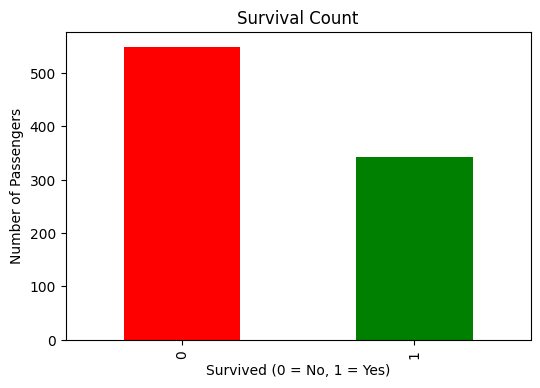

In [30]:
plt.figure(figsize=(6,4))

df["Survived"].value_counts().plot(kind="bar", color=["red","green"])

plt.title("Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")

plt.show()


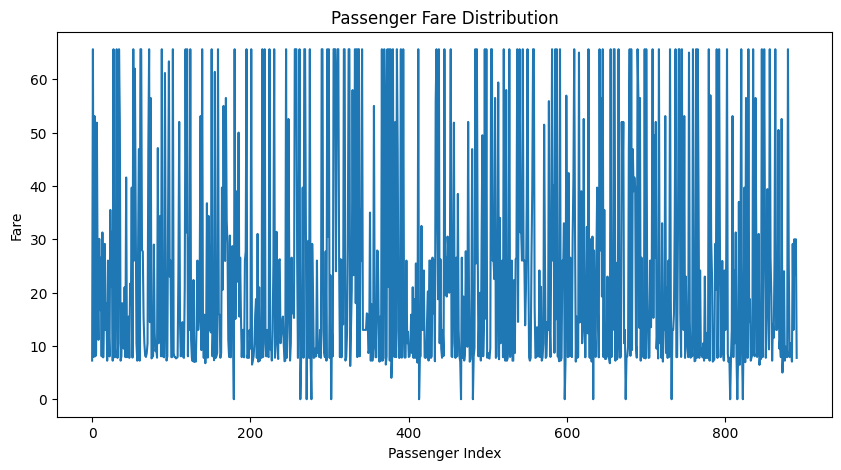

In [31]:
plt.figure(figsize=(10,5))

plt.plot(df["Fare"])

plt.title("Passenger Fare Distribution")
plt.xlabel("Passenger Index")
plt.ylabel("Fare")

plt.show()

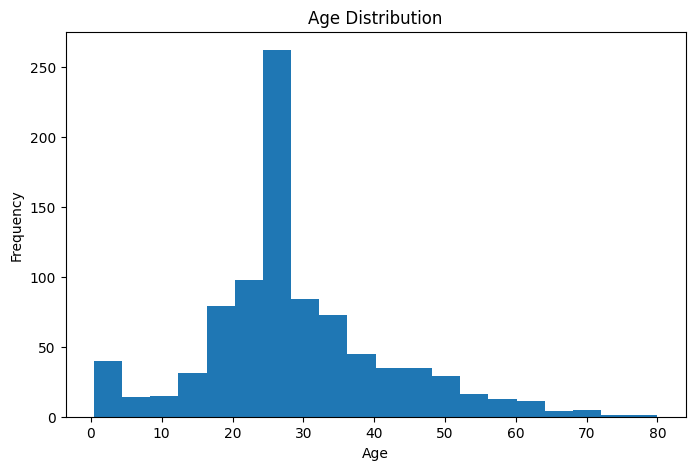

In [32]:
plt.figure(figsize=(8,5))

plt.hist(df["Age"], bins=20)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

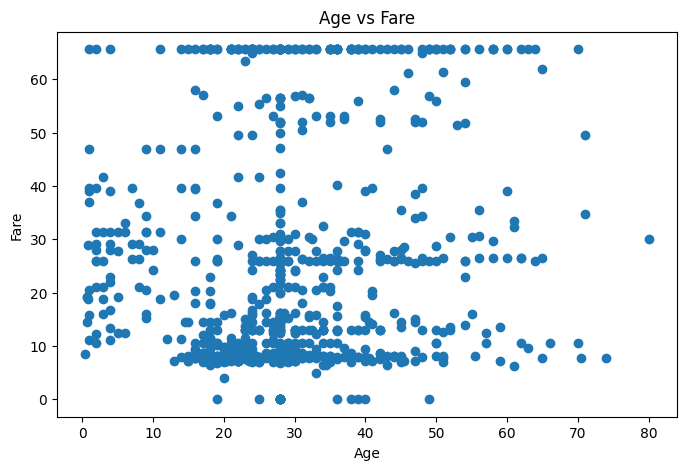

In [33]:
plt.figure(figsize=(8,5))

plt.scatter(df["Age"], df["Fare"])

plt.title("Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")

plt.show()

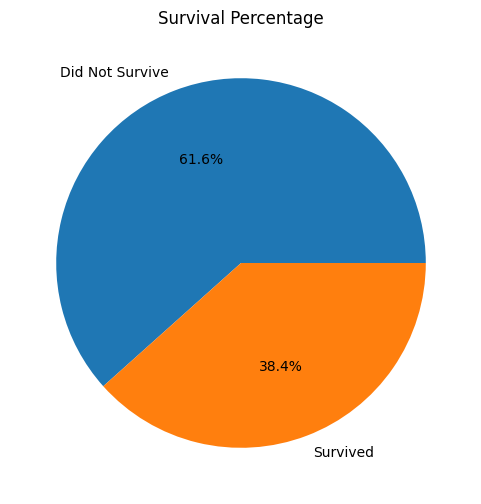

In [34]:
plt.figure(figsize=(6,6))

df["Survived"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    labels=["Did Not Survive","Survived"]
)

plt.title("Survival Percentage")

plt.ylabel("")

plt.show()

# Titanic Data Cleaning & Passenger Analysis - EDA Summary

## Objective
Analyze passenger survival trends using the Titanic dataset.

## Dataset Overview
- Total Records: 891
- Total Features: 12 (Cabin removed during cleaning)

## Data Cleaning
- Missing values in Age were filled using the median.
- Missing values in Embarked were filled using the mode.
- Cabin column was removed because it contained many missing values.
- No duplicate records were found.

## Statistical Analysis
- Calculated mean, median, mode, variance, and standard deviation.

## Outlier Detection
- Fare outliers were identified using the IQR method and capped.

## GroupBy Analysis
- First-class passengers had the highest survival rate.
- Third-class passengers had the lowest survival rate.

## Visualizations
- Bar Chart
- Line Chart
- Histogram
- Scatter Plot
- Pie Chart

## Conclusion
Passenger class had a strong influence on survival. First-class passengers were much more likely to survive than third-class passengers.